# Cohort Analysis — Customer Retention

A cohort is a group of customers who made their first purchase in the same month. Tracking cohorts over time tells us how well the business retains customers — one of the most important metrics in retail.

**Question we're answering:** Of the customers who first bought in month X, what percentage came back in the following months?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv('../data/online_retail_raw.csv', parse_dates=['InvoiceDate'])

# Keep only valid transactions
df_clean = df[
    df['CustomerID'].notna() &
    ~df['InvoiceNo'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Data loaded:", df_clean.shape)

Data loaded: (397884, 9)


In [ ]:
## 1. Assigning Cohorts

Each customer is assigned to the cohort of their first purchase month.
We then calculate how many months after that first purchase each transaction occurred.

In [4]:
# Get first purchase month per customer
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['InvoiceMonth']\
    .transform('min')

# Calculate months since first purchase
def period_diff(a, b):
    return (a.year - b.year) * 12 + (a.month - b.month)

df_clean['CohortIndex'] = df_clean.apply(
    lambda x: period_diff(x['InvoiceMonth'], x['CohortMonth']), axis=1
)

print(df_clean[['CustomerID','InvoiceMonth','CohortMonth','CohortIndex']].head(10))

   CustomerID InvoiceMonth CohortMonth  CohortIndex
0       17850      2010-12     2010-12            0
1       17850      2010-12     2010-12            0
2       17850      2010-12     2010-12            0
3       17850      2010-12     2010-12            0
4       17850      2010-12     2010-12            0
5       17850      2010-12     2010-12            0
6       17850      2010-12     2010-12            0
7       17850      2010-12     2010-12            0
8       17850      2010-12     2010-12            0
9       13047      2010-12     2010-12            0


## 2. Building the Cohort Table

In [5]:
# Count unique customers per cohort and month index
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']\
    .nunique().reset_index()

cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

# Calculate retention rates
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

print("Cohort table shape:", retention.shape)
print(retention.iloc[:5, :6])

Cohort table shape: (13, 13)
CohortIndex      0     1     2     3     4     5
CohortMonth                                     
2010-12      100.0  36.6  32.3  38.4  36.3  39.8
2011-01      100.0  22.1  26.6  23.0  32.1  28.8
2011-02      100.0  18.7  18.7  28.4  27.1  24.7
2011-03      100.0  15.0  25.2  19.9  22.3  16.8
2011-04      100.0  21.3  20.3  21.0  19.7  22.7


## 3. Retention Heatmap
A heatmap makes it easy to spot retention patterns across all cohorts at once.

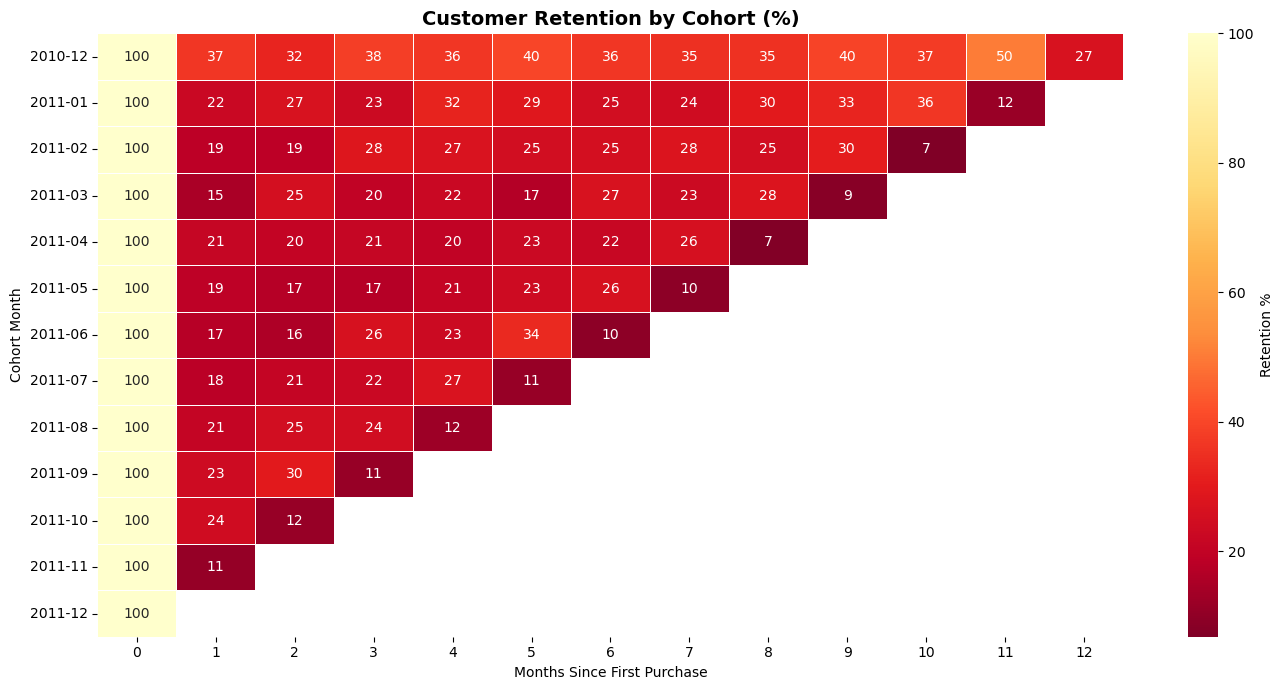

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    retention,
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Retention %'}
)
ax.set_title('Customer Retention by Cohort (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('../reports/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- The **Dec-2010 cohort** shows the strongest long-term retention (~35-40%), likely established wholesale buyers using this store as a regular supplier.
- All cohorts lose 60-80% of customers after month 1 — typical for wholesale retail but signals a significant retention challenge for new customers.
- Mid-2011 cohorts (May–August) show the weakest retention, suggesting new customers acquired outside peak season are less likely to return.
- **Recommendation:** Focus acquisition efforts on Q4 when customers show higher lifetime retention, and invest in onboarding for new customers to survive month 1.